<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   418 non-null    int64  
 1   PassengerId  418 non-null    int64  
 2   Survived     418 non-null    int64  
 3   Pclass       418 non-null    int64  
 4   Name         418 non-null    object 
 5   Sex          418 non-null    object 
 6   Age          332 non-null    float64
 7   SibSp        418 non-null    int64  
 8   Parch        418 non-null    int64  
 9   Ticket       418 non-null    object 
 10  Fare         417 non-null    float64
 11  Cabin        91 non-null     object 
 12  Embarked     418 non-null    object 
dtypes: float64(2), int64(6), object(5)
memory usage: 42.6+ KB


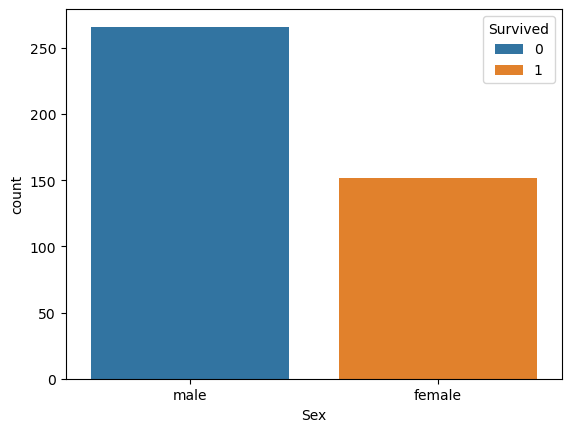

Accuracy Score:  1.0
[[42  0]
 [ 0 25]]


C:\Users\sayan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix

#load dataset
df=pd.read_csv('tested.csv')
df.head()
df.info()
df.describe()
#check for missing values
df.isnull().sum()

#Drop unnecessary columns, including 'Name', which contains string values
df.drop(['Cabin', 'Ticket', 'Fare', 'Name', 'PassengerId'], axis=1, inplace=True)

#Data Visualization
sns.countplot(x='Sex',hue='Survived',data=df)
plt.show()

#Convert categorical variables to numeric
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

#Handle any remaining missing values
df = df.dropna()  # Or use imputation methods like df.fillna()

#Feature and Target Split
X=df.drop('Survived', axis=1)
y=df['Survived']

#Train Test Dataset
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)

#Train Model
model= LogisticRegression()
model.fit(X_train,y_train)

#Prediction
y_predict=model.predict(X_test)

# Evaluation
print("Accuracy Score: ",accuracy_score(y_test,y_predict))
print(confusion_matrix(y_test,y_predict))